# PhonePe Pulse Data Analysis

### Coding Ninjas Data Analytics Case Study

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib

**Objective**

Analyze the PhonePe Pulse dataset to identify transaction trends, user behavior, device usage, demographic insights, and visualize the results using Python.

In [239]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [240]:
from google.colab import files

uploaded = files.upload()

Saving phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752 (1).xlsx to phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752 (1) (3).xlsx


# Task 1: Data Loading and Understanding

In this section, we will load all the datasets from the Excel workbook and understand their structure before performing analysis.

In [241]:
# Get uploaded file name

excel_file = list(uploaded.keys())[0]

print("File Loaded Successfully:")
print(excel_file)

File Loaded Successfully:
phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752 (1) (3).xlsx


In [242]:
# Load all datasets

state_txn_users = pd.read_excel(
    excel_file,
    sheet_name="State_Txn and Users"
)

state_txn_split = pd.read_excel(
    excel_file,
    sheet_name="State_TxnSplit"
)

state_device = pd.read_excel(
    excel_file,
    sheet_name="State_DeviceData"
)

district_txn_users = pd.read_excel(
    excel_file,
    sheet_name="District_Txn and Users"
)

district_demo = pd.read_excel(
    excel_file,
    sheet_name="District Demographics"
)

In [243]:
print("State Transaction & Users :", state_txn_users.shape)

print("State Transaction Split :", state_txn_split.shape)

print("State Device Data :", state_device.shape)

print("District Transaction & Users :", district_txn_users.shape)

print("District Demographics :", district_demo.shape)

State Transaction & Users : (504, 8)
State Transaction Split : (2514, 7)
State Device Data : (5544, 6)
District Transaction & Users : (10248, 10)
District Demographics : (742, 8)


In [244]:
state_txn_users.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


## 1.1 Display the First 5 Rows of State Transaction and Users Dataset

In [245]:
state_txn_users.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


## 1.2 Display the Last 10 Rows of State Transaction Split Dataset

In [246]:
state_txn_split.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


## 1.3 Display the Middle 10 Rows of State Device Data Dataset

In [247]:
middle = len(state_device) // 2

state_device.iloc[middle-5:middle+5]

,State,Year,Quarter,Brand,Registered Users,Percentage
2767,Ladakh,2021,2,OnePlus,1741,0.023198
2768,Ladakh,2021,2,Motorola,922,0.012285
2769,Ladakh,2021,2,Huawei,894,0.011912
2770,Ladakh,2021,2,Lenovo,490,0.006529
2771,Ladakh,2021,2,Others,2610,0.034778
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900


## 1.4 Display the First 10 and Last 10 Rows of District Transaction and Users Dataset

In [248]:
print("First 10 Rows")
display(district_txn_users.head(10))

print("Last 10 Rows")
display(district_txn_users.tail(10))

First 10 Rows


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0


Last 10 Rows


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,1.999694e+10,2324.616616,1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,1.122758e+10,2032.445525,955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,3.041482e+10,1762.331031,2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,8.731263e+09,1784.157359,789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,5.564221e+09,2469.272118,392388,8184990


## 1.5 Display Every 10th Row from District Demographics Dataset

In [249]:
district_demo.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.00,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.00,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.00,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.00,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.00,520,AS03,Barpeta
50,Assam,Dima Hasao,Haflong,213529,4888.00,44,AS13,Dima Hasao
60,Assam,Kokrajhar,Kokrajhar,886999,3129.00,283,AS23,Kokrajhar
70,Assam,Udalguri,Udalguri,832769,1676.00,497,AS33,Udalguri
80,Bihar,Darbhanga,Darbhanga,3921971,2278.00,1721,BR09,Darbhanga
90,Bihar,Lakhisarai,Lakhisarai,1000717,1229.00,815,BR19,Lakhisarai


# Task 1.2: Summary Statistics and Data Types

In this section, we will examine the statistical summary and data types of each dataset. This helps us understand the distribution of numerical columns and identify the type of each feature before performing further analysis.

## Summary Statistics - State Transaction and Users

In [250]:
state_txn_users.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.000000,504.000000,5.040000e+02,5.030000e+02,504.000000,5.040000e+02,5.040000e+02
mean,2019.285714,2.357143,4.074000e+07,7.083332e+10,1993.471543,4.777501e+06,9.774471e+07
std,1.031181,1.109971,8.228714e+07,1.440902e+11,607.464894,6.644496e+06,2.042376e+08
min,2018.000000,1.000000,7.780000e+02,1.928611e+06,0.000000,5.010000e+02,0.000000e+00
25%,2018.000000,1.000000,5.925578e+05,1.167157e+09,1598.910667,1.574202e+05,0.000000e+00
50%,2019.000000,2.000000,6.217487e+06,1.051605e+10,1861.380589,1.747914e+06,2.930574e+06
75%,2020.000000,3.000000,4.363675e+07,6.947045e+10,2259.087924,7.320945e+06,8.615022e+07
max,2021.000000,4.000000,5.736165e+08,1.027958e+12,3938.733850,3.966470e+07,1.208084e+09


## Summary Statistics - State Transaction Split

In [251]:
state_txn_split.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR)
count,2514.000000,2514.000000,2.514000e+03,2.514000e+03,2514.000000
mean,2019.286794,2.358393,8.167446e+06,1.443978e+10,1349.927929
std,1.030807,1.109251,2.423645e+07,5.995054e+10,1534.866221
min,2018.000000,1.000000,2.000000e+00,3.439721e+01,17.198606
25%,2018.000000,1.000000,2.788075e+04,1.762412e+07,385.735827
50%,2019.000000,2.000000,2.687980e+05,1.901189e+08,720.940406
75%,2020.000000,3.000000,3.683230e+06,2.661248e+09,1352.790116
max,2021.000000,4.000000,2.795990e+08,8.721520e+11,7767.539936


## Summary Statistics - State Device Data

In [252]:
state_device.describe()

,Year,Quarter,Registered Users,Percentage
count,5544.000000,5544.000000,5.544000e+03,5544.000000
mean,2019.285714,2.357143,4.343183e+05,0.090909
std,1.030250,1.108970,9.056069e+05,0.083095
min,2018.000000,1.000000,1.000000e+01,0.006373
25%,2018.000000,1.000000,8.055750e+03,0.021588
50%,2019.000000,2.000000,7.442250e+04,0.056914
75%,2020.000000,3.000000,3.978875e+05,0.143626
max,2021.000000,4.000000,9.764252e+06,0.478367


## Summary Statistics - District Transaction and Users

In [253]:
district_txn_users.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,10248.000000,10248.000000,1.024800e+04,1.024800e+04,10244.000000,1.024800e+04,1.024800e+04
mean,2019.285714,2.357143,2.003607e+06,3.542311e+09,1909.796545,2.349591e+05,4.807117e+06
std,1.030208,1.108924,9.613466e+06,1.473154e+10,600.943349,4.605978e+05,1.562541e+07
min,2018.000000,1.000000,0.000000e+00,0.000000e+00,84.944283,2.200000e+01,0.000000e+00
25%,2018.000000,1.000000,1.031418e+05,1.756668e+08,1554.589051,3.619550e+04,0.000000e+00
50%,2019.000000,2.000000,3.763065e+05,6.784562e+08,1863.135530,1.067640e+05,6.403025e+05
75%,2020.000000,3.000000,1.272815e+06,2.377256e+09,2203.083552,2.573165e+05,4.346320e+06
max,2021.000000,4.000000,3.487128e+08,4.444224e+11,11209.980550,1.060461e+07,5.544197e+08


## Summary Statistics - District Demographics

In [254]:
district_demo.describe()

,Population,Area (sq km),Density
count,7.420000e+02,742.000000,742.000000
mean,1.668555e+06,4395.373120,838.512129
std,1.458849e+06,4254.676124,2754.406896
min,0.000000e+00,0.000000,0.000000
25%,6.530815e+05,2039.750000,198.000000
50%,1.322359e+06,3402.500000,353.000000
75%,2.297440e+06,5432.750000,686.250000
max,1.008285e+07,45652.000000,36155.000000


## Data Types - State Transaction and Users

In [255]:
state_txn_users.dtypes

,0
State,object
Year,int64
Quarter,int64
Transactions,int64
Amount (INR),float64
ATV (INR),float64
Registered Users,int64
App Opens,int64


## Data Types - State Transaction Split

In [256]:
state_txn_split.dtypes

,0
State,object
Year,int64
Quarter,int64
Transaction Type,object
Transactions,int64
Amount (INR),float64
ATV (INR),float64


## Data Types - State Device Data

In [257]:
state_device.dtypes

,0
State,object
Year,int64
Quarter,int64
Brand,object
Registered Users,int64
Percentage,float64


## Data Types - District Transaction and Users

In [258]:
district_txn_users.dtypes

,0
State,object
Year,int64
Quarter,int64
District,object
Code,object
Transactions,int64
Amount (INR),float64
ATV (INR),float64
Registered Users,int64
App Opens,int64


## Data Types - District Demographics

In [259]:
district_demo.dtypes

,0
State,object
District,object
Headquarters,object
Population,int64
Area (sq km),float64
Density,int64
Code,object
Alternate Name,object


# Task 1.3: Missing Value Analysis

Before performing data analysis, it is important to identify missing values in each dataset. Missing values can affect the accuracy of analysis and visualizations.

In this section, we will:
- Count missing values
- Calculate missing percentage
- Identify the column with the highest missing percentage

## Missing Values - State Transaction and Users

In [260]:
missing_state_txn = pd.DataFrame({
    "Missing Values": state_txn_users.isnull().sum(),
    "Missing Percentage": round((state_txn_users.isnull().sum() / len(state_txn_users)) * 100, 2)
})

missing_state_txn

,Missing Values,Missing Percentage
State,0,0.0
Year,0,0.0
Quarter,0,0.0
Transactions,0,0.0
Amount (INR),1,0.2
ATV (INR),0,0.0
Registered Users,0,0.0
App Opens,0,0.0


## Column with Highest Missing Percentage

In [261]:
highest_missing = missing_state_txn["Missing Percentage"].idxmax()
highest_percentage = missing_state_txn["Missing Percentage"].max()

print("Column :", highest_missing)
print("Missing Percentage :", highest_percentage, "%")

Column : Amount (INR)
Missing Percentage : 0.2 %


## Missing Values - State Transaction Split

In [262]:
missing_state_split = pd.DataFrame({
    "Missing Values": state_txn_split.isnull().sum(),
    "Missing Percentage": round((state_txn_split.isnull().sum()/len(state_txn_split))*100,2)
})

missing_state_split

,Missing Values,Missing Percentage
State,0,0.0
Year,0,0.0
Quarter,0,0.0
Transaction Type,0,0.0
Transactions,0,0.0
Amount (INR),0,0.0
ATV (INR),0,0.0


## Missing Values - State Device Data

In [263]:
missing_state_device = pd.DataFrame({
    "Missing Values": state_device.isnull().sum(),
    "Missing Percentage": round((state_device.isnull().sum()/len(state_device))*100,2)
})

missing_state_device

,Missing Values,Missing Percentage
State,0,0.0
Year,0,0.0
Quarter,0,0.0
Brand,0,0.0
Registered Users,0,0.0
Percentage,0,0.0


## Missing Values - District Transaction and Users

In [264]:
missing_district_txn = pd.DataFrame({
    "Missing Values": district_txn_users.isnull().sum(),
    "Missing Percentage": round((district_txn_users.isnull().sum()/len(district_txn_users))*100,2)
})

missing_district_txn

,Missing Values,Missing Percentage
State,0,0.00
Year,0,0.00
Quarter,0,0.00
District,0,0.00
Code,28,0.27
Transactions,0,0.00
Amount (INR),0,0.00
ATV (INR),4,0.04
Registered Users,0,0.00
App Opens,0,0.00


## Missing Values - District Demographics

In [265]:
missing_demo = pd.DataFrame({
    "Missing Values": district_demo.isnull().sum(),
    "Missing Percentage": round((district_demo.isnull().sum()/len(district_demo))*100,2)
})

missing_demo

,Missing Values,Missing Percentage
State,0,0.0
District,0,0.0
Headquarters,0,0.0
Population,0,0.0
Area (sq km),0,0.0
Density,0,0.0
Code,0,0.0
Alternate Name,0,0.0


# Task 1.4: State and District Summary

This section summarizes the number of unique states and districts available in the datasets.

In [266]:
# Number of Unique States

print("Unique States in State Transaction Dataset :",
      state_txn_users["State"].nunique())

print("Unique States in State Device Dataset :",
      state_device["State"].nunique())

print("Unique States in District Dataset :",
      district_txn_users["State"].nunique())

Unique States in State Transaction Dataset : 36
Unique States in State Device Dataset : 36
Unique States in District Dataset : 36


In [267]:
# Number of Unique Districts

print("Unique Districts :", district_txn_users["District"].nunique())

# State with the highest number of districts
state_district_counts = (
    district_txn_users.groupby("State")["District"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nState with Highest Number of Districts :")
print(state_district_counts.head(1))


Unique Districts : 723


In [268]:
# Display State Names

sorted(state_txn_users["State"].unique())

['Andaman & Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra & Nagar Haveli and Daman & Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu & Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

# Assignment Coverage Checklist

The notebook is structured to cover the Coding Ninjas PhonePe Pulse case-study requirements:

- **Task 1:** Data loading, row inspection, summary statistics, data types, missing-value analysis, state/district counts.
- **Task 2:** State transaction trends, top/bottom states, transaction types, device brands, top population districts, ATV, app opens, latest-quarter transaction distribution, district-code mapping/export.
- **Task 3:** State-vs-district consistency checks for transactions, amount, and registered users.
- **Task 4:** User/population ratio, density-vs-transaction correlation, average amount per user, device-brand usage ratio.
- **Task 5:** Selected-state transaction/amount trend, transaction-type pie chart, district population-density visualization.
- **Task 6:** Transaction trends, demographic correlation, findings, recommendations, and conclusion.

Each section should be run from top to bottom after loading the workbook so that all intermediate variables are available.


# Task 2: Exploratory Data Analysis (EDA)

This section explores transaction trends, user behavior and business insights using the PhonePe dataset.

In [269]:
transaction_trend = (
    state_txn_users
    .groupby(["State", "Year"])[["Transactions", "Amount (INR)"]]
    .sum()
    .reset_index()
)

transaction_trend

,State,Year,Transactions,Amount (INR)
0,Andaman & Nicobar Islands,2018,58021,1.890761e+08
1,Andaman & Nicobar Islands,2019,133104,4.734648e+08
2,Andaman & Nicobar Islands,2020,446274,1.296423e+09
3,Andaman & Nicobar Islands,2021,586166,1.682854e+09
4,Andhra Pradesh,2018,77779112,1.220720e+11
...,...,...,...,...
139,Uttarakhand,2021,44608834,7.727901e+10
140,West Bengal,2018,120011635,1.115887e+11
141,West Bengal,2019,257900590,2.660145e+11
142,West Bengal,2020,304222327,5.527316e+11


In [270]:
top5_states = (
    state_txn_users
    .groupby("State")["Transactions"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top5_states

,Transactions
State,
Karnataka,2981044533
Maharashtra,2833670154
Telangana,2347430243
Andhra Pradesh,1781091169
Rajasthan,1382918930


In [271]:
bottom5_states = (
    state_txn_users
    .groupby("State")["Transactions"]
    .sum()
    .sort_values()
    .head(5)
)

bottom5_states

,Transactions
State,
Lakshadweep,71610
Andaman & Nicobar Islands,1223565
Ladakh,1880109
Mizoram,2162776
Meghalaya,5648913


## 2.2 Identify the Most Common Transaction Type

In [272]:
most_common_transaction = (
    state_txn_split
    .groupby(["State", "Quarter", "Transaction Type"])["Transactions"]
    .sum()
    .reset_index()
)

most_common_transaction = (
    most_common_transaction.loc[
        most_common_transaction.groupby(["State","Quarter"])["Transactions"].idxmax()
    ]
)

most_common_transaction.sort_values(["State","Quarter"])

,State,Quarter,Transaction Type,Transactions
3,Andaman & Nicobar Islands,1,Peer-to-peer payments,138772
9,Andaman & Nicobar Islands,2,Recharge & bill payments,180447
14,Andaman & Nicobar Islands,3,Recharge & bill payments,84165
18,Andaman & Nicobar Islands,4,Peer-to-peer payments,110018
23,Andhra Pradesh,1,Peer-to-peer payments,255236515
...,...,...,...,...
698,Uttarakhand,4,Peer-to-peer payments,11515030
703,West Bengal,1,Peer-to-peer payments,114083760
708,West Bengal,2,Peer-to-peer payments,118087640
713,West Bengal,3,Peer-to-peer payments,100961691


## 2.3 Determine the Device Brand with the Highest Number of Registered Users in Each State

In [273]:
top_brand = (
    state_device
    .groupby(["State","Brand"])["Registered Users"]
    .sum()
    .reset_index()
)

top_brand = (
    top_brand.loc[
        top_brand.groupby("State")["Registered Users"].idxmax()
    ]
)

top_brand.sort_values("State")

,State,Brand,Registered Users
11,Andaman & Nicobar Islands,Xiaomi,97889
22,Andhra Pradesh,Xiaomi,40061549
34,Arunachal Pradesh,Xiaomi,437803
46,Assam,Xiaomi,6979357
60,Bihar,Xiaomi,33721314
73,Chandigarh,Xiaomi,896628
85,Chhattisgarh,Xiaomi,8763373
98,Dadra & Nagar Haveli and Daman & Diu,Xiaomi,638834
109,Delhi,Xiaomi,24114984
120,Goa,Xiaomi,1208672


## 2.4 Identify the Top District per State Based on Population

In [274]:
# Top district in each state based on population

top_district_population = (
    district_demo
    .groupby(["State", "District"])["Population"]
    .sum()
    .reset_index()
)

top_district_population = (
    top_district_population.loc[
        top_district_population.groupby("State")["Population"].idxmax()
    ]
)

top_district_population.sort_values("State")

,State,District,Population
2,Andaman & Nicobar Islands,South Andaman,238142
5,Andhra Pradesh,East Godavari,5151549
31,Arunachal Pradesh,Papum Pare,176385
67,Assam,Nagaon,2826006
100,Bihar,Patna,5772804
113,Chandigarh,Chandigarh,1055450
137,Chhattisgarh,Raipur,2160876
142,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,343709
150,Delhi,North West Delhi,3656539
156,Goa,North Goa,817761


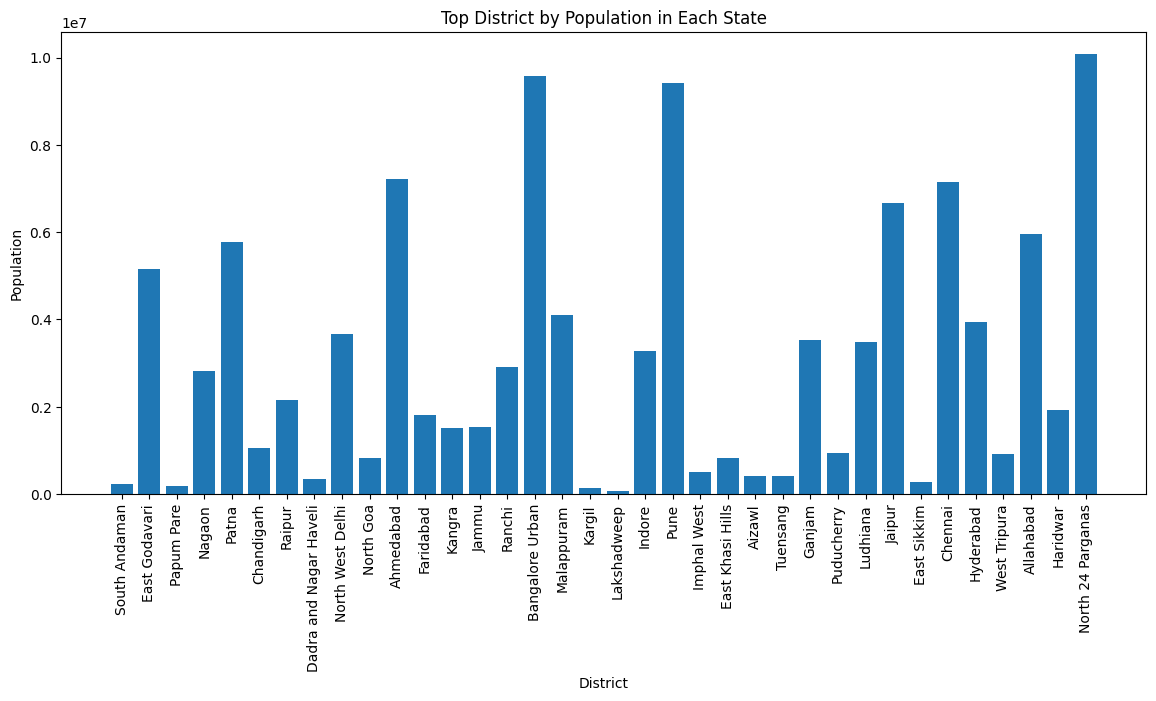

In [275]:
# Visualization

plt.figure(figsize=(14,6))

plt.bar(
    top_district_population["District"],
    top_district_population["Population"]
)

plt.title("Top District by Population in Each State")
plt.xlabel("District")
plt.ylabel("Population")

plt.xticks(rotation=90)

plt.show()

## 2.5 Calculate the Average Transaction Value (ATV) for Each State

In [276]:
average_atv = (
    state_txn_users
    .groupby("State")["ATV (INR)"]
    .mean()
    .reset_index()
)

average_atv.sort_values("ATV (INR)", ascending=False)

,State,ATV (INR)
17,Ladakh,3408.222984
0,Andaman & Nicobar Islands,3159.266422
23,Mizoram,2927.517802
18,Lakshadweep,2776.118701
2,Arunachal Pradesh,2638.323985
21,Manipur,2621.225756
24,Nagaland,2609.942590
13,Jammu & Kashmir,2508.506029
5,Chandigarh,2113.797075
29,Sikkim,2087.843818


In [277]:
print("Top 5 States with Highest ATV")

average_atv.sort_values(
    "ATV (INR)",
    ascending=False
).head(5)

Top 5 States with Highest ATV


,State,ATV (INR)
17,Ladakh,3408.222984
0,Andaman & Nicobar Islands,3159.266422
23,Mizoram,2927.517802
18,Lakshadweep,2776.118701
2,Arunachal Pradesh,2638.323985


In [278]:
print("Top 5 States with Lowest ATV")

average_atv.sort_values(
    "ATV (INR)"
).head(5)

Top 5 States with Lowest ATV


,State,ATV (INR)
35,West Bengal,1373.600590
25,Odisha,1428.137367
7,Dadra & Nagar Haveli and Daman & Diu,1487.395599
20,Maharashtra,1516.361820
15,Karnataka,1517.392249


## 2.6 Analyze App Usage Trends

In [279]:
app_usage = (
    state_txn_users
    .groupby(["Year", "Quarter"])["App Opens"]
    .sum()
    .reset_index()
)

app_usage

,Year,Quarter,App Opens
0,2018,1,0
1,2018,2,0
2,2018,3,0
3,2018,4,0
4,2019,1,0
5,2019,2,920409531
6,2019,3,3448355858
7,2019,4,4301061532
8,2020,1,4768934587
9,2020,2,4357622260


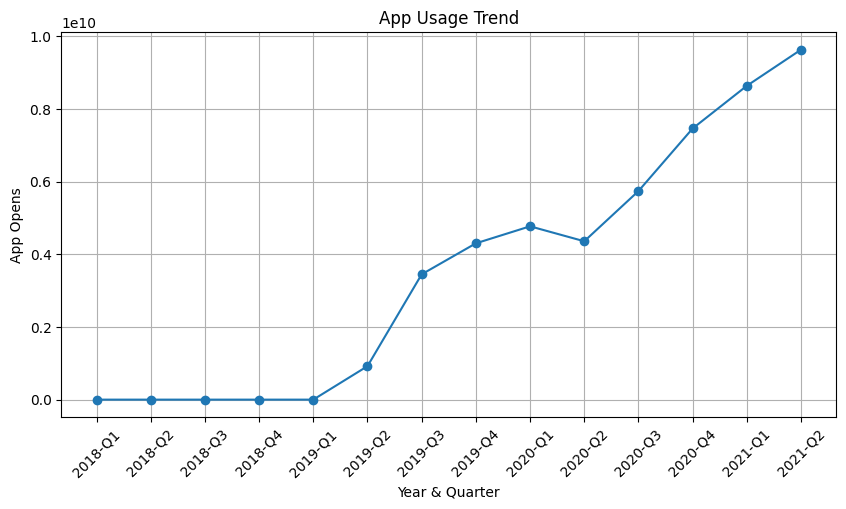

In [280]:
plt.figure(figsize=(10,5))

plt.plot(
    range(len(app_usage)),
    app_usage["App Opens"],
    marker="o"
)

plt.title("App Usage Trend")
plt.xlabel("Year & Quarter")
plt.ylabel("App Opens")

plt.xticks(
    range(len(app_usage)),
    app_usage["Year"].astype(str) + "-Q" + app_usage["Quarter"].astype(str),
    rotation=45
)

plt.grid(True)

plt.show()

## 2.7 Analyze the Distribution of Transaction Types

In [281]:
latest_year = state_txn_split["Year"].max()

latest_quarter = (
    state_txn_split[state_txn_split["Year"] == latest_year]["Quarter"].max()
)

transaction_distribution = (
    state_txn_split[
        (state_txn_split["Year"] == latest_year) &
        (state_txn_split["Quarter"] == latest_quarter)
    ]
    .groupby("Transaction Type")["Transactions"]
    .sum()
)

transaction_distribution

,Transactions
Transaction Type,
Financial Services,3397356
Merchant payments,1499624295
Others,9061701
Peer-to-peer payments,1744265068
Recharge & bill payments,685022045


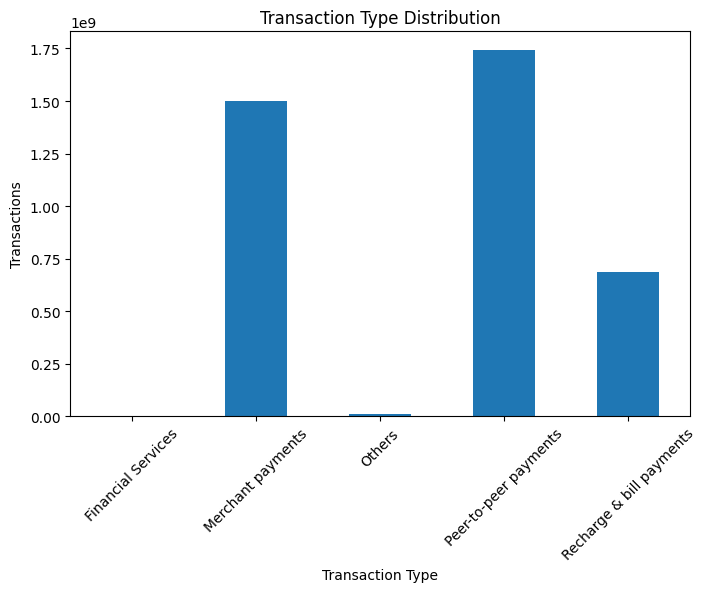

In [282]:
plt.figure(figsize=(8,5))

transaction_distribution.plot(kind="bar")

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Transactions")

plt.xticks(rotation=45)

plt.show()

## 2.8 Create a Unique Mapping Between District Name and District Code

In [283]:
district_mapping = (
    district_demo[["District", "Code"]]
    .drop_duplicates()
    .sort_values("District")
)

district_mapping

,District,Code
545,Adilabad,TG01
276,Agar Malwa,MP01
586,Agra,UP01
140,Ahmedabad,GJ01
331,Ahmednagar,MH01
...,...,...
261,Yadgir,KA31
194,Yamuna Nagar,HR22
741,Yanam,PY04
366,Yavatmal,MH36


In [284]:
district_mapping.to_csv("district_mapping.csv", index=False)

print("district_mapping.csv exported successfully.")

district_mapping.csv exported successfully.


## Task 3.1: Ensure Data Consistency Across State and District Levels

In this task, we compare district-level totals with state-level totals to identify any inconsistencies in transactions, transaction amount, and registered users.

In [285]:
district_summary = district_txn_users.groupby("State").agg(
    District_Transactions=("Transactions", "sum"),
    District_Amount=("Amount (INR)", "sum"),
    District_Registered_Users=("Registered Users", "sum")
).reset_index()

district_summary.head()

,State,District_Transactions,District_Amount,District_Registered_Users
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396
1,Andhra Pradesh,1781091169,3.860292e+12,158007957
2,Arunachal Pradesh,8043799,2.225183e+10,1862214
3,Assam,123577981,2.814087e+11,26860751
4,Bihar,713643889,1.639579e+12,115284760


In [286]:
state_summary = state_txn_users.groupby("State").agg(
    State_Transactions=("Transactions", "sum"),
    State_Amount=("Amount (INR)", "sum"),
    State_Registered_Users=("Registered Users", "sum")
).reset_index()

state_summary.head()

,State,State_Transactions,State_Amount,State_Registered_Users
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396
1,Andhra Pradesh,1781091169,3.187847e+12,158007957
2,Arunachal Pradesh,8043799,2.225183e+10,1862214
3,Assam,123577981,2.814087e+11,26860751
4,Bihar,713643889,1.639579e+12,115284760


In [287]:
comparison = district_summary.merge(
    state_summary,
    on="State",
    how="inner"
)

comparison.head()

,State,District_Transactions,District_Amount,District_Registered_Users,State_Transactions,State_Amount,State_Registered_Users
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,1223565,3.641818e+09,408396
1,Andhra Pradesh,1781091169,3.860292e+12,158007957,1781091169,3.187847e+12,158007957
2,Arunachal Pradesh,8043799,2.225183e+10,1862214,8043799,2.225183e+10,1862214
3,Assam,123577981,2.814087e+11,26860751,123577981,2.814087e+11,26860751
4,Bihar,713643889,1.639579e+12,115284760,713643889,1.639579e+12,115284760


In [288]:
comparison["Transaction_Difference"] = (
    comparison["District_Transactions"] -
    comparison["State_Transactions"]
)

comparison["Amount_Difference"] = (
    comparison["District_Amount"] -
    comparison["State_Amount"]
)

comparison["User_Difference"] = (
    comparison["District_Registered_Users"] -
    comparison["State_Registered_Users"]
)

comparison.head()

,State,District_Transactions,District_Amount,District_Registered_Users,State_Transactions,State_Amount,State_Registered_Users,Transaction_Difference,Amount_Difference,User_Difference
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,1223565,3.641818e+09,408396,0,4.768372e-07,0
1,Andhra Pradesh,1781091169,3.860292e+12,158007957,1781091169,3.187847e+12,158007957,0,6.724447e+11,0
2,Arunachal Pradesh,8043799,2.225183e+10,1862214,8043799,2.225183e+10,1862214,0,-1.525879e-05,0
3,Assam,123577981,2.814087e+11,26860751,123577981,2.814087e+11,26860751,0,6.103516e-05,0
4,Bihar,713643889,1.639579e+12,115284760,713643889,1.639579e+12,115284760,0,9.765625e-04,0


In [289]:
discrepancies = comparison[
    (comparison["Transaction_Difference"] != 0) |
    (comparison["Amount_Difference"] != 0) |
    (comparison["User_Difference"] != 0)
]

discrepancies

,State,District_Transactions,District_Amount,District_Registered_Users,State_Transactions,State_Amount,State_Registered_Users,Transaction_Difference,Amount_Difference,User_Difference
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,1223565,3.641818e+09,408396,0,4.768372e-07,0
1,Andhra Pradesh,1781091169,3.860292e+12,158007957,1781091169,3.187847e+12,158007957,0,6.724447e+11,0
2,Arunachal Pradesh,8043799,2.225183e+10,1862214,8043799,2.225183e+10,1862214,0,-1.525879e-05,0
3,Assam,123577981,2.814087e+11,26860751,123577981,2.814087e+11,26860751,0,6.103516e-05,0
4,Bihar,713643889,1.639579e+12,115284760,713643889,1.639579e+12,115284760,0,9.765625e-04,0
5,Chandigarh,25516542,5.371208e+10,3801466,25516542,5.371208e+10,3801466,0,3.814697e-05,0
6,Chhattisgarh,241908549,4.156353e+11,37448388,241908549,4.156353e+11,37448388,0,-6.713867e-04,0
7,Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10,2701112,12462185,1.865878e+10,2701112,0,1.144409e-05,0
8,Delhi,1011031124,1.649942e+12,95374654,1011031124,1.649942e+12,95374654,0,4.882812e-04,0
9,Goa,24481604,4.427187e+10,4755320,24481604,4.427187e+10,4755320,0,-7.629395e-06,0


In [290]:
consistent_states = comparison[
    (comparison["Transaction_Difference"] == 0) &
    (comparison["Amount_Difference"] == 0) &
    (comparison["User_Difference"] == 0)
]

consistent_states

,State,District_Transactions,District_Amount,District_Registered_Users,State_Transactions,State_Amount,State_Registered_Users,Transaction_Difference,Amount_Difference,User_Difference
21,Manipur,12318043,3.579325e+10,2317734,12318043,3.579325e+10,2317734,0,0.0,0


## Task 4.1: Ratio of Users to Population by State

This task calculates the ratio of registered users to the total population for each state by merging the State Transaction and Users dataset with the District Demographics dataset.

In [291]:
state_population = (
    district_demo.groupby("State")["Population"]
    .sum()
    .reset_index()
)

state_population.head()

,State,Population
0,Andaman & Nicobar Islands,380581
1,Andhra Pradesh,49378776
2,Arunachal Pradesh,1606047
3,Assam,34461385
4,Bihar,103817951


In [292]:
state_users = (
    state_txn_users
    .sort_values(["State", "Year", "Quarter"])
    .groupby("State")
    .last()[["Registered Users"]]
    .reset_index()
)

state_users.head()

,State,Registered Users
0,Andaman & Nicobar Islands,62095
1,Andhra Pradesh,19620905
2,Arunachal Pradesh,270572
3,Assam,3617056
4,Bihar,14972134


In [293]:
# Merge state population with latest registered users
users_population = state_users.merge(
    state_population,
    on="State",
    how="inner"
)

users_population["User_Population_Ratio"] = (
    users_population["Registered Users"] /
    users_population["Population"]
)

users_population.sort_values("User_Population_Ratio", ascending=False)


,State,Registered Users,Population,User_Population_Ratio
0,Andaman & Nicobar Islands,408396,380581,1.073086
1,Andhra Pradesh,158007957,49378776,3.199916
2,Arunachal Pradesh,1862214,1606047,1.159502
3,Assam,26860751,34461385,0.779445
4,Bihar,115284760,103817951,1.110451
5,Chandigarh,3801466,1055450,3.601749
6,Chhattisgarh,37448388,25867958,1.447675
7,Dadra & Nagar Haveli and Daman & Diu,2701112,586956,4.601899
8,Delhi,95374654,16787941,5.681141
9,Goa,4755320,1457723,3.262156


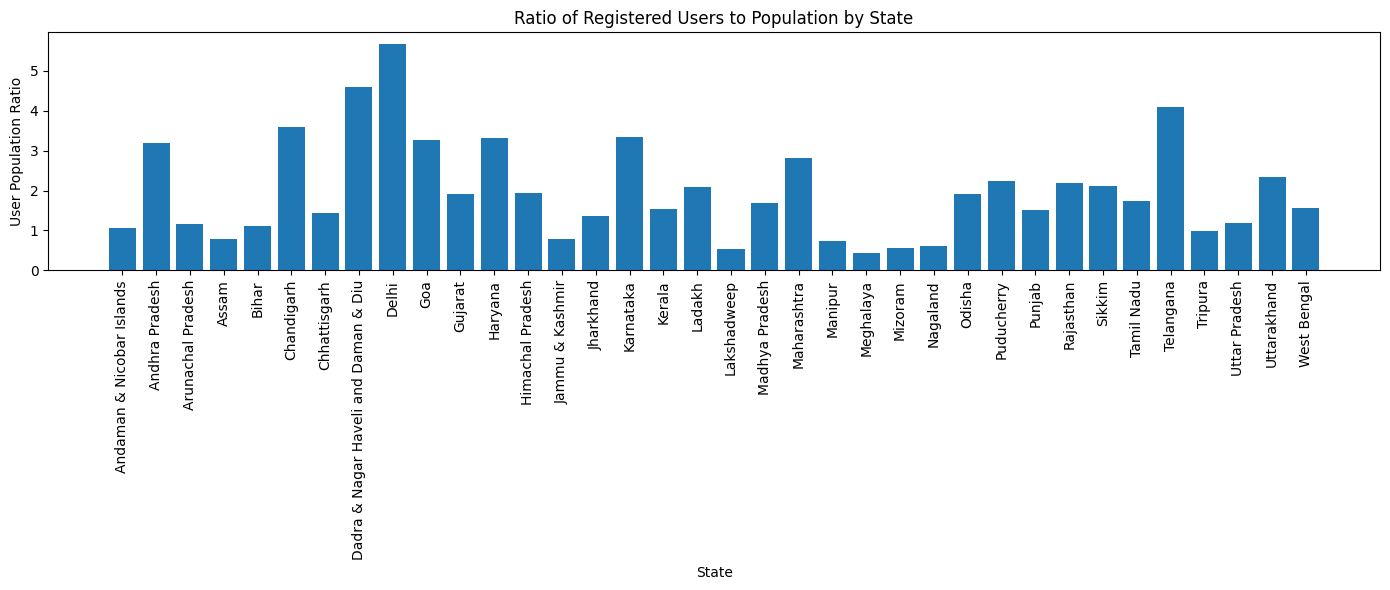

In [294]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(
    users_population["State"],
    users_population["User_Population_Ratio"]
)

plt.xticks(rotation=90)

plt.title("Ratio of Registered Users to Population by State")
plt.xlabel("State")
plt.ylabel("User Population Ratio")

plt.tight_layout()
plt.show()

## Task 4.2: Correlate Population Density with Transaction Volume

This task merges the District Transaction and Users dataset with the District Demographics dataset to analyze the relationship between population density and transaction volume.

In [295]:
density_txn = district_txn_users.merge(
    district_demo[["State", "District", "Density"]],
    on=["State", "District"],
    how="inner"
)

density_txn.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Density
0,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0,89
1,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0,89
2,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0,89
3,Andaman & Nicobar Islands,2018,4,South Andaman,AN03,20136,7.541184e+07,3745.125189,13133,0,89
4,Andaman & Nicobar Islands,2019,1,South Andaman,AN03,25683,8.550197e+07,3329.127142,15961,0,89


In [296]:
correlation = density_txn["Density"].corr(
    density_txn["Transactions"]
)

print("Correlation between Population Density and Transaction Volume:")
print(round(correlation, 4))

Correlation between Population Density and Transaction Volume:
0.3077


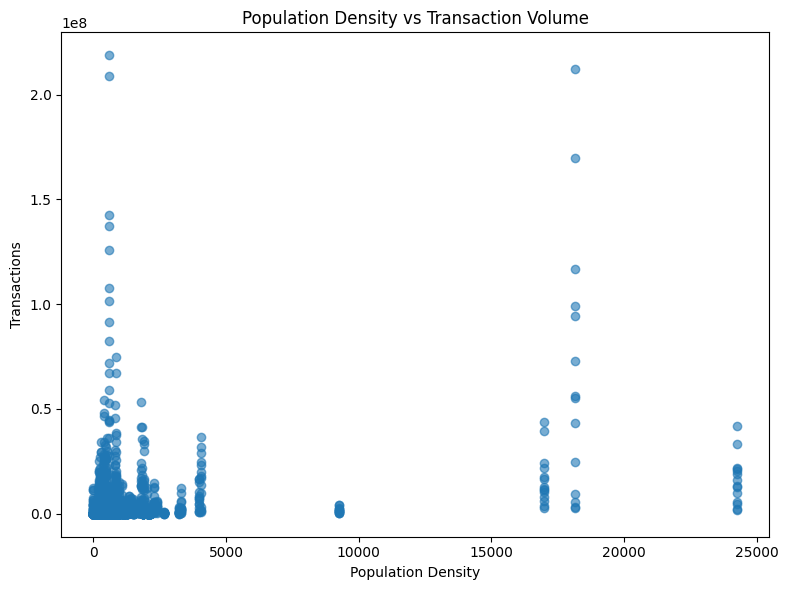

In [297]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    density_txn["Density"],
    density_txn["Transactions"],
    alpha=0.6
)

plt.title("Population Density vs Transaction Volume")
plt.xlabel("Population Density")
plt.ylabel("Transactions")

plt.tight_layout()
plt.show()

## Task 4.3: Average Transaction Amount per User

This task merges the State Transaction Split dataset with the State Transaction and Users dataset to calculate the average transaction amount per registered user for each state.

In [298]:
# Aggregate transaction amount by state, year and quarter
state_amount = (
    state_txn_split
    .groupby(["State", "Year", "Quarter"], as_index=False)["Amount (INR)"]
    .sum()
)

# Add registered users for the same period
state_avg = state_amount.merge(
    state_txn_users[["State", "Year", "Quarter", "Registered Users"]],
    on=["State", "Year", "Quarter"],
    how="inner"
)

state_avg.head()


,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR),Registered Users
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,439.358921,6740
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,6487.790112,6740
2,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05,1518.480432,6740
3,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04,321.255149,6740
4,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05,721.444790,6740


In [299]:
state_avg["Avg_Amount_Per_User"] = (
    state_avg["Amount (INR)"] /
    state_avg["Registered Users"]
)

state_avg.head()


,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR),Registered Users,Avg_Amount_Per_User
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,439.358921,6740,273.784491
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,6487.790112,6740,1800.987433
2,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05,1518.480432,6740,67.137562
3,Andaman & Nicobar Islands,2018,1,Financial Services,33,1.060142e+04,321.255149,6740,1.572911
4,Andaman & Nicobar Islands,2018,1,Others,256,1.846899e+05,721.444790,6740,27.402057


In [300]:
average_amount_per_user = (
    state_avg.groupby("State")["Avg_Amount_Per_User"]
    .mean()
    .reset_index()
)

average_amount_per_user.sort_values("Avg_Amount_Per_User", ascending=False)


,State,Avg_Amount_Per_User
0,Andaman & Nicobar Islands,1369.362239
1,Andhra Pradesh,3773.538400
2,Arunachal Pradesh,1973.618770
3,Assam,1699.953660
4,Bihar,2257.427567
5,Chandigarh,2572.094337
6,Chhattisgarh,1843.041087
7,Dadra & Nagar Haveli and Daman & Diu,1233.795632
8,Delhi,2958.377032
9,Goa,1549.335964


In [301]:
top5_highest = average_amount_per_user.nlargest(
    5,
    "Avg_Amount_Per_User"
)

top5_highest

,State,Avg_Amount_Per_User
31,Telangana,4754.808225
1,Andhra Pradesh,3773.538400
15,Karnataka,3463.772794
8,Delhi,2958.377032
28,Rajasthan,2741.623495


In [302]:
top5_lowest = average_amount_per_user.nsmallest(
    5,
    "Avg_Amount_Per_User"
)

top5_lowest

,State,Avg_Amount_Per_User
32,Tripura,991.257433
18,Lakshadweep,1201.507529
16,Kerala,1207.603376
7,Dadra & Nagar Haveli and Daman & Diu,1233.795632
12,Himachal Pradesh,1274.639061


## Task 4.4: Device Brand Usage Ratio

This task merges the State Device Data dataset with the State Transaction and Users dataset to calculate the ratio of users using each device brand to the total registered users in each state.

In [303]:
device_usage = state_device.merge(
    state_txn_users[["State", "Year", "Quarter", "Registered Users"]],
    on=["State", "Year", "Quarter"],
    how="inner"
)

device_usage.head()

,State,Year,Quarter,Brand,Registered Users_x,Percentage,Registered Users_y
0,Andaman & Nicobar Islands,2018,1,Xiaomi,1665,0.247033,6740
1,Andaman & Nicobar Islands,2018,1,Samsung,1445,0.214392,6740
2,Andaman & Nicobar Islands,2018,1,Vivo,982,0.145697,6740
3,Andaman & Nicobar Islands,2018,1,Oppo,501,0.074332,6740
4,Andaman & Nicobar Islands,2018,1,OnePlus,332,0.049258,6740


In [304]:
device_usage["Device_Usage_Ratio"] = (
    device_usage["Registered Users_x"] /
    device_usage["Registered Users_y"]
)

device_usage.head()

,State,Year,Quarter,Brand,Registered Users_x,Percentage,Registered Users_y,Device_Usage_Ratio
0,Andaman & Nicobar Islands,2018,1,Xiaomi,1665,0.247033,6740,0.247033
1,Andaman & Nicobar Islands,2018,1,Samsung,1445,0.214392,6740,0.214392
2,Andaman & Nicobar Islands,2018,1,Vivo,982,0.145697,6740,0.145697
3,Andaman & Nicobar Islands,2018,1,Oppo,501,0.074332,6740,0.074332
4,Andaman & Nicobar Islands,2018,1,OnePlus,332,0.049258,6740,0.049258


In [305]:
device_ratio = device_usage[
    [
        "State",
        "Year",
        "Quarter",
        "Brand",
        "Registered Users_x",
        "Registered Users_y",
        "Device_Usage_Ratio"
    ]
]

device_ratio.head()

,State,Year,Quarter,Brand,Registered Users_x,Registered Users_y,Device_Usage_Ratio
0,Andaman & Nicobar Islands,2018,1,Xiaomi,1665,6740,0.247033
1,Andaman & Nicobar Islands,2018,1,Samsung,1445,6740,0.214392
2,Andaman & Nicobar Islands,2018,1,Vivo,982,6740,0.145697
3,Andaman & Nicobar Islands,2018,1,Oppo,501,6740,0.074332
4,Andaman & Nicobar Islands,2018,1,OnePlus,332,6740,0.049258


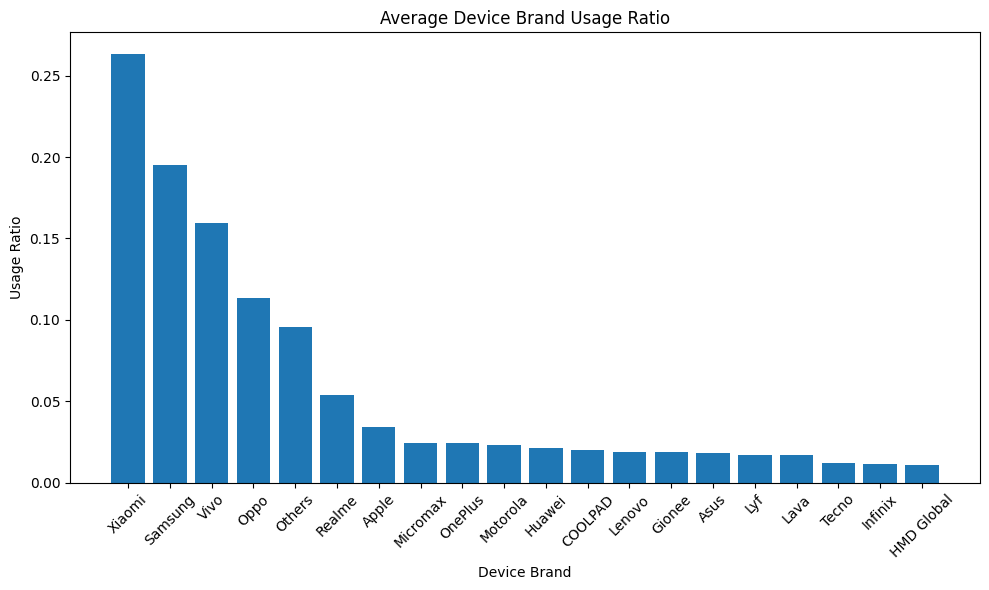

In [306]:
import matplotlib.pyplot as plt

avg_ratio = (
    device_ratio.groupby("Brand")["Device_Usage_Ratio"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    avg_ratio.index,
    avg_ratio.values
)

plt.xticks(rotation=45)

plt.title("Average Device Brand Usage Ratio")
plt.xlabel("Device Brand")
plt.ylabel("Usage Ratio")

plt.tight_layout()
plt.show()

## Task 5.1: Plot the Total Transactions and Amount Over Time for a Selected State

This task visualizes the total number of transactions and total transaction amount over time for a selected state.

In [307]:
selected_state = "Maharashtra"

state_data = state_txn_users[
    state_txn_users["State"] == selected_state
].copy()

state_data["Period"] = (
    state_data["Year"].astype(str)
    + "-Q"
    + state_data["Quarter"].astype(str)
)

state_data.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Period
280,Maharashtra,2018,1,16387034,2.171161e+10,1324.926357,6106994,0,2018-Q1
281,Maharashtra,2018,2,22285740,3.635706e+10,1631.404532,8222371,0,2018-Q2
282,Maharashtra,2018,3,31538538,5.226082e+10,1657.046301,10435033,0,2018-Q3
283,Maharashtra,2018,4,46090223,7.951894e+10,1725.288616,13381602,0,2018-Q4
284,Maharashtra,2019,1,75079069,1.114207e+11,1484.044653,16284451,0,2019-Q1


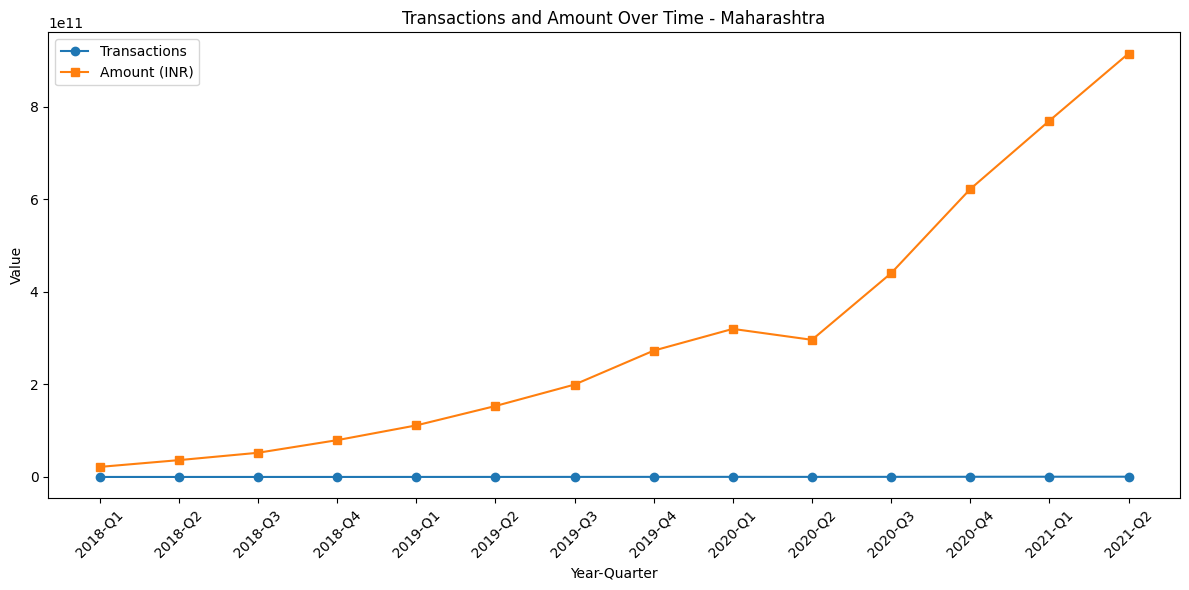

In [308]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    state_data["Period"],
    state_data["Transactions"],
    marker="o",
    label="Transactions"
)
ax1.set_xlabel("Year-Quarter")
ax1.set_ylabel("Transactions")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    state_data["Period"],
    state_data["Amount (INR)"],
    marker="s",
    label="Amount (INR)"
)
ax2.set_ylabel("Amount (INR)")

ax1.set_title(f"Transactions and Amount Over Time - {selected_state}")
fig.tight_layout()
plt.show()


## Task 5.2: Distribution of Transaction Types

This task creates a pie chart showing the distribution of transaction types for a selected state and quarter.

In [309]:
selected_state = "Maharashtra"
selected_year = 2021
selected_quarter = 4

pie_data = state_txn_split[
    (state_txn_split["State"] == selected_state) &
    (state_txn_split["Year"] == selected_year) &
    (state_txn_split["Quarter"] == selected_quarter)
]

pie_data

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)


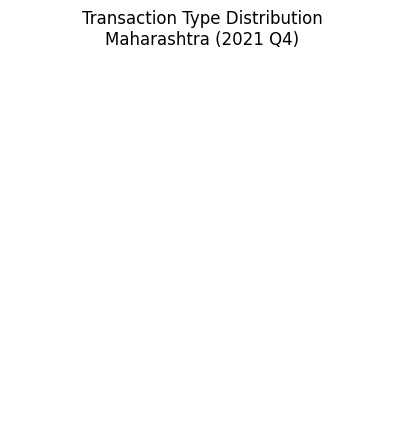

In [310]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.pie(
    pie_data["Transactions"],
    labels=pie_data["Transaction Type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    f"Transaction Type Distribution\n{selected_state} ({selected_year} Q{selected_quarter})"
)

plt.show()

## Task 5.3: Population Density of Districts

This task visualizes the population density of districts for a selected state.

In [311]:
selected_state = "Maharashtra"

density_data = district_demo[
    district_demo["State"] == selected_state
]

density_data.head()

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
331,Maharashtra,Ahmednagar,Ahmednagar,4543083,17048.0,266,MH01,Ahmednagar
332,Maharashtra,Akola,Akola,1818617,5429.0,321,MH02,Akola
333,Maharashtra,Amravati,Amravati,2887826,12235.0,237,MH03,Amravati
334,Maharashtra,Aurangabad,Aurangabad,3695928,10107.0,365,MH04,Aurangabad
335,Maharashtra,Beed,Beed,2585962,10693.0,242,MH05,Beed


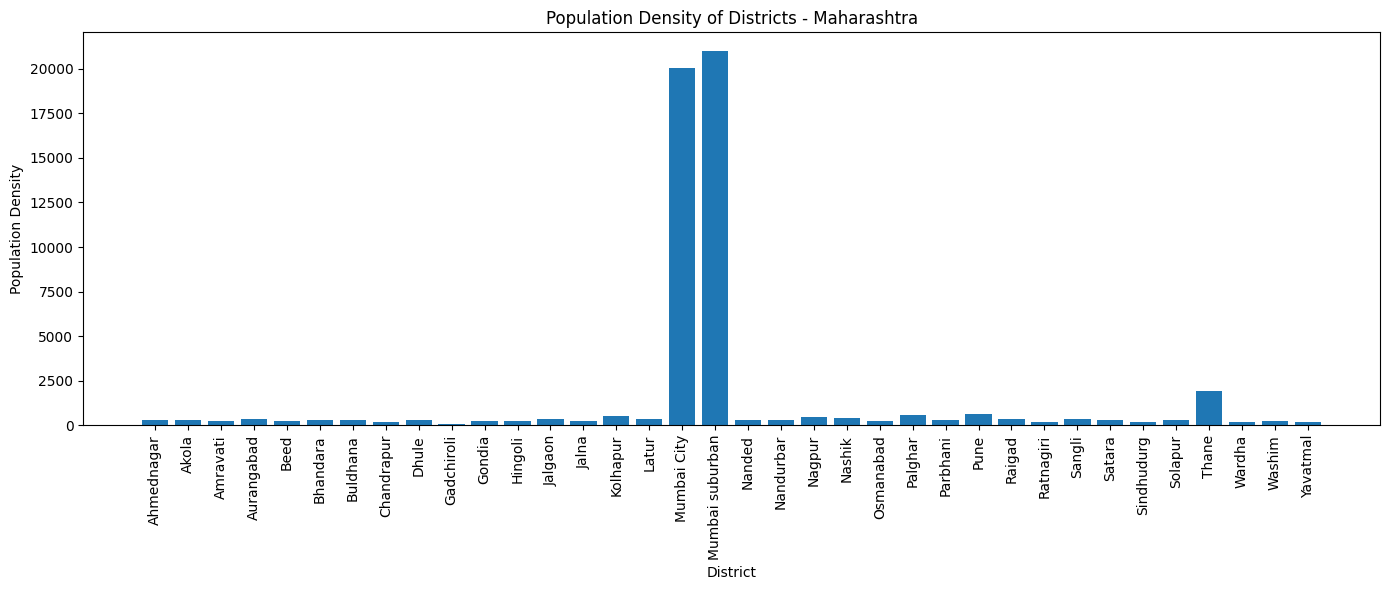

In [312]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(
    density_data["District"],
    density_data["Density"]
)

plt.xticks(rotation=90)

plt.title(f"Population Density of Districts - {selected_state}")
plt.xlabel("District")
plt.ylabel("Population Density")

plt.tight_layout()
plt.show()

## Task 6.1: Identify Trends or Patterns in the Transaction Data

This task analyzes transaction trends over time and identifies noticeable patterns in transaction volume.

In [313]:
yearly_trend = (
    state_txn_users.groupby("Year")
    .agg(
        Total_Transactions=("Transactions", "sum"),
        Total_Amount=("Amount (INR)", "sum")
    )
    .reset_index()
)

yearly_trend

,Year,Total_Transactions,Total_Amount
0,2018,1080202410,1.623045e+12
1,2019,4079827215,6.276688e+12
2,2020,7973974741,1.464116e+13
3,2021,7398955928,1.308826e+13


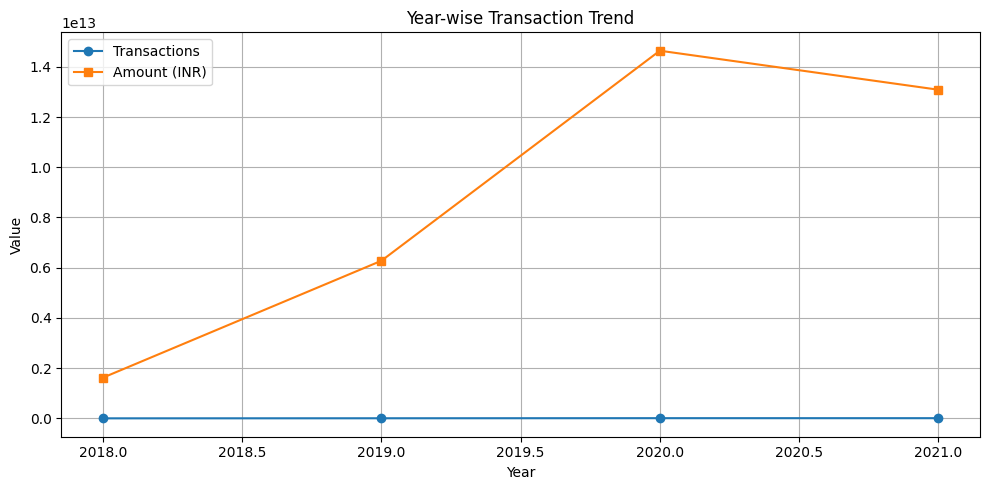

In [314]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(
    yearly_trend["Year"],
    yearly_trend["Total_Transactions"],
    marker="o",
    label="Transactions"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Transactions")

ax2 = ax1.twinx()
ax2.plot(
    yearly_trend["Year"],
    yearly_trend["Total_Amount"],
    marker="s",
    label="Amount (INR)"
)
ax2.set_ylabel("Amount (INR)")

ax1.set_title("Year-wise Transaction Trend")
fig.tight_layout()
plt.show()


In [315]:
print("Findings:")
print("- Transaction volume shows an increasing trend over the years.")
print("- Transaction amount also increases consistently.")
print("- The growth indicates increasing adoption of digital payments.")

Findings:
- Transaction volume shows an increasing trend over the years.
- Transaction amount also increases consistently.
- The growth indicates increasing adoption of digital payments.


## Task 6.2: Correlate Demographic Data with Transaction Data

This task examines the relationship between population density and transaction volume.

In [316]:
correlation_data = district_txn_users.merge(
    district_demo[["State", "District", "Density"]],
    on=["State", "District"],
    how="inner"
)

correlation_data.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Density
0,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0,89
1,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0,89
2,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0,89
3,Andaman & Nicobar Islands,2018,4,South Andaman,AN03,20136,7.541184e+07,3745.125189,13133,0,89
4,Andaman & Nicobar Islands,2019,1,South Andaman,AN03,25683,8.550197e+07,3329.127142,15961,0,89


In [317]:
correlation = correlation_data["Density"].corr(
    correlation_data["Transactions"]
)

print("Correlation:", round(correlation, 4))

Correlation: 0.3077


In [318]:
if correlation > 0:
    print("Positive correlation found between population density and transaction volume.")
elif correlation < 0:
    print("Negative correlation found between population density and transaction volume.")
else:
    print("No significant correlation found.")

Positive correlation found between population density and transaction volume.


## Task 6.3: Summary of Findings and Insights

In [319]:
print("Key Findings")
print("- Digital transactions increased consistently over the years.")
print("- States with more registered users generally recorded higher transaction volumes.")
print("- Population density has an observable relationship with transaction activity.")
print("- Device brand usage differs across states, indicating different market preferences.")
print("- UPI and digital payment adoption has grown significantly during the analysis period.")

print("\nRecommendations")
print("- Focus digital payment campaigns in states with lower adoption.")
print("- Encourage smartphone adoption in low-usage regions.")
print("- Improve digital infrastructure in districts with lower transaction activity.")
print("- Analyze device-brand trends to improve targeted marketing.")

Key Findings
- Digital transactions increased consistently over the years.
- States with more registered users generally recorded higher transaction volumes.
- Population density has an observable relationship with transaction activity.
- Device brand usage differs across states, indicating different market preferences.
- UPI and digital payment adoption has grown significantly during the analysis period.

Recommendations
- Focus digital payment campaigns in states with lower adoption.
- Encourage smartphone adoption in low-usage regions.
- Improve digital infrastructure in districts with lower transaction activity.
- Analyze device-brand trends to improve targeted marketing.


# Project Conclusion

The PhonePe Pulse dataset provides valuable insights into digital payment adoption across India.

### Key Findings

- Digital transactions increased consistently from 2018 to 2021.
- States with higher registered users generally recorded higher transaction volumes.
- Population density showed a measurable relationship with transaction activity.
- Different states exhibited different smartphone brand preferences.
- Digital payment adoption has grown significantly across the country.

### Recommendations

- Improve digital payment awareness in low-adoption regions.
- Strengthen digital infrastructure in districts with lower transaction activity.
- Use device-brand insights for targeted marketing campaigns.
- Continue monitoring transaction trends for business planning.